## This notebook will test using a tensor DNN to try to get similar performance to the paper

Will attempt to get a testing implementation working to try optimising parameters.

In [2]:
import glob
import json
import os
import time
from collections.abc import Sized, Iterable

import optuna
from optuna import Trial
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Configuration

Notes among variables

* Batch normalisation reduces need for dropout highlighted in original paper
* Dropout still appears to help at lower percentage
* Adding depth to DNN much better than adding width in manual testing
* Dropout of first layer is a disaster and I don't know why I thought it would be good

In [3]:
#
csv_path = "./HIGGS.csv"

# Folder for every completed model + a JSON of its params/AUC.
# .pruned file is output so we don't redo pruned trains
MODEL_DIR = "models-new-do-all-low-test"
os.makedirs(MODEL_DIR, exist_ok=True)
# --- feature set -----------------------------------------------------
# 28 columns total. Columns 1-21 are the "low-level" kinematic features
# columns 22-28 are the 7 "high-level" derived features (m_jj ... m_wwbb)
feature_set = "low"               # "all" | "low"

# --- architecture ----------------------------------------------------
# Paper's best: "five-layer" net = 4 hidden x 300 + output
# hidden_layers = [300, 300, 300, 300, 300, 300, 300]
# hidden_layers = [600, 600, 600, 600]
# GELU appears best!
#act_layer = nn.GELU # nn.ReLU, nn.SiLU nn.Tanh, or possibly nn.GELU

# with no batch normalisation, more dropout is better - 50% better than 20%
# batchnorm enabled with no dropout is significantly better than 50% dropout without batch normalisation
# batch normalisation plus 50% dropout is a slight improvement, but 20% is a bigger improvement
# batch normalisation mitigates the need for dropout and makes a smaller percentage perform better
#batchnorm = True                  # stabiliser see paper https://arxiv.org/abs/1502.03167 - nn.BatchNorm1d

#dropout = 0.2                     # paper applied 50% dropout to the TOP hidden layer
#initial_dropout = 0.0


# --- optimisation ----------------------------------------------------
epochs = 100                       # 100 assuming we will reach patience limit prior
batch_size = 8192                 # big batches keep the GPU busy; paper used 100 (2011 GPU)
# max_lr = 0.003                     # OneCycle peak LR for AdamW
max_lr = 0.005                     # OneCycle peak LR for AdamW
weight_decay = 0.00001               # matches the paper's L2 coefficient
label_smoothing = 0.0             # try 0.01-0.05 if the net overfits

# --- engineering -----------------------------------------------------
keep_data_on_gpu = True
early_stop_patience = 10 # stop if val AUC hasn't improved for this many epochs
seed = 1337

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Read and split the data

In [4]:

data = pd.read_csv(csv_path, header=None, dtype=np.float32)

arr = data.to_numpy()


In [5]:
y = arr[:, 0].astype(np.int8)      # first column = label
X = arr[:, 1:].astype(np.float32)  # remaining 28 columns = features

if feature_set == "low":
    X = X[:, :21]

X_train, X_val1, y_train, y_val1 = train_test_split(X, y, test_size=0.0909090909, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_val1, y_val1, test_size=0.5, random_state=42)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)
print(y_train.shape)
print(y_val.shape)
print(y_test.shape)


# X_train_small, X_val1_small, y_train_small, y_val1_small = train_test_split(X_small, y_small, test_size=0.0909090909, random_state=42)
# X_val_small, X_test_small, y_val_small, y_test_small = train_test_split(X_val1_small, y_val1_small, test_size=0.5, random_state=42)

(10000000, 21)
(500000, 21)
(500000, 21)
(10000000,)
(500000,)
(500000,)


#### Model class

Creates the DNN

In [6]:

class HiggsMLP(nn.Module):

    def __init__(self,
                 in_dim: int,
                 hidden_layers: list[int],
                 last_layer_dropout: float,
                 all_layer_dropout: float,
                 act_layer
             ):
        super().__init__()

        layers = []
        prev = in_dim
        n_hidden = len(hidden_layers)
        for i, width in enumerate(hidden_layers):
            layers.append(nn.Linear(prev, width))
            # batchnorm consistently better than dropout alone
            layers.append(nn.BatchNorm1d(width))
            layers.append(act_layer())
            is_last_hidden = (i == n_hidden - 1)
            if all_layer_dropout > 5e-3 and not is_last_hidden:
                layers.append(nn.Dropout(all_layer_dropout))
            elif last_layer_dropout > 0 and is_last_hidden:
                layers.append(nn.Dropout(last_layer_dropout))
            prev = width

        layers.append(nn.Linear(prev, 1))    # single logit for binary classification
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)        # shape [B] to match the label vector

#### Trainer

Method to use the above class to train a model. Using a static method so we can pass everything in, and don't accidentally use a variable from the global scope.

In [7]:
torch.manual_seed(seed)
np.random.seed(seed)
# TF32 matmuls: free accuracy-for-speed trade on NVIDIA GPUs for fp32 ops.
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [13]:

# No-grad - use for inference to reduce memory
@torch.no_grad()
def compute_auc(model, X_gpu, y_np, batch: int = 65536):
    model.eval()
    probs = []
    for i in range(0, len(X_gpu), batch):
        logits = model(X_gpu[i:i + batch])
        probs.append(torch.sigmoid(logits).float().cpu().numpy())
    return roc_auc_score(y_np, np.concatenate(probs))


def build_hidden_internal(depth, base, shape): # -> int, int, str, list[int]:
    if shape == "uniform":
        return [base] * depth
    # pyramid: halve each layer, floor at 64
    return [max(64, base // (2 ** i)) for i in range(depth)]

def build_hidden(trial): # -> int, int, str, list[int]: # idk why i can't get a solid return type
    depth = trial.suggest_int("depth", 3, 8)
    base = trial.suggest_categorical("base_width", [256, 384, 512, 640, 768, 1024])
    shape = trial.suggest_categorical("shape", ["uniform", "pyramid"])
    return depth, base, shape, build_hidden_internal(depth, base, shape)

class TrainingHelper:

    @staticmethod
    def train(
            trial: Trial,
            hidden_layers: list[int],
            X_train, # : arr[arr[float]], would really love to give these data types but honestly it's unclear what they should be
            y_train, # : arr[arr[float]],
            X_val, # : ndarray[torch.float32],
            y_val,
            act_func,
            epochs: int,
            max_lr: float,
            weight_decay: float,
            last_layer_dropout: float,
            all_layer_dropout: float,
            batch_size: int,
            device,
            tag: str
    ):

        to_gpu = True
        Xtr_t = torch.tensor(X_train, device=device if to_gpu else "cpu")
        ytr_t = torch.tensor(y_train, dtype=torch.float32, device=device if to_gpu else "cpu")
        Xva_t = torch.tensor(X_val, device=device)

        # ---- model / loss / optimiser --------------------------------------
        model = HiggsMLP(
            in_dim=X_train.shape[1],
            hidden_layers=hidden_layers,
            last_layer_dropout=last_layer_dropout,
            all_layer_dropout=all_layer_dropout,
            act_layer=act_func
        ).to(device)

        try:
            model = torch.compile(model)
            print("torch.compile: enabled")
        except Exception as e:
            print(f"torch.compile failed ({e}); continuing uncompiled")

        # BCEWithLogitsLoss = sigmoid + binary cross-entropy, fused & numerically stable.
        loss_fn = nn.BCEWithLogitsLoss()
        # AdamW is the modern default (decoupled weight decay)
        opt = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
        # Basic, similar to original paper
        # opt = torch.optim.SGD(model.parameters(), lr=0.05, momentum=0.9, weight_decay=1e-5)

        n_train = len(Xtr_t)
        steps_per_epoch = (n_train + batch_size - 1) // batch_size

        # schedule for MLPs; a modern replacement for the paper's slow manual decay.
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=max_lr,
            epochs=epochs, steps_per_epoch=steps_per_epoch,
            pct_start=0.1  # was having an issue where patience would run out before lr would decay - want to keep training for up to 100 but likely will never go that long
        )

        # bfloat16 autocast: half-precision math on the GPU, ~2x throughput. bf16
        # (unlike fp16) has enough dynamic range that NO GradScaler is needed.
        amp_ctx = (torch.autocast("cuda", dtype=torch.bfloat16)
                   if DEVICE.type == "cuda"
                   else torch.autocast("cuda", enabled=False))

        best_auc, best_state, epochs_no_improve = 0.0, None, 0
        for epoch in range(epochs):
            model.train()
            t0 = time.perf_counter()
            perm = torch.randperm(n_train, device=Xtr_t.device)  # fresh shuffle each epoch
            running = 0.0
            for i in range(0, n_train, batch_size):
                idx = perm[i:i + batch_size]
                xb = Xtr_t[idx]
                yb = ytr_t[idx]
                if not to_gpu:                       # only needed if data is on CPU
                    xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)

                opt.zero_grad(set_to_none=True)      # set_to_none is slightly faster than zeroing
                with amp_ctx:
                    logits = model(xb)
                    loss = loss_fn(logits, yb)
                loss.backward()
                opt.step()
                sched.step()
                running += loss.item() * len(idx)

            val_auc = compute_auc(model, Xva_t, y_val)
            dt = time.perf_counter() - t0

            # Early stopping: keep the best-on-validation weights, stop if stalled.
            if val_auc > best_auc + 0.0001:
                best_auc = val_auc
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if trial is None and epochs_no_improve >= early_stop_patience:
                return best_auc, best_state
            elif trial is not None:
                trial.report(val_auc, epoch)
                if trial.should_prune() or epochs_no_improve >= early_stop_patience:
                    with open(os.path.join(MODEL_DIR, f"{tag}.pruned"), "w") as f:
                        pass
                    raise optuna.TrialPruned()

        return best_auc, best_state


activation_types = {"relu": nn.ReLU, "tanh": nn.Tanh, "gelu": nn.GELU}
BATCHES = [8192, 16384, 32768]

def objective(trial):
    depth, base, shape, hidden = build_hidden(trial)
    act = trial.suggest_categorical("act", ["relu", "gelu"])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    dropout_all = trial.suggest_float("dropout_all", 0.0, 0.15)
    lr = trial.suggest_float("max_lr", 1e-3, 4e-3, log=True)
    wd = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch = trial.suggest_categorical("batch", BATCHES)


    tag = (f"trial{trial.number}_d{depth}_{shape}_w{base}_{act}"
           f"_do{dropout:.3f}_doa{dropout_all:.3f}_lr{lr:.5f}_wd{wd:.2e}_b{batch}")
    if os.path.exists(os.path.join(MODEL_DIR, f"{tag}.json")):
        with open(os.path.join(MODEL_DIR, f"{tag}.json")) as jsonFile:
            fileData = json.load(jsonFile)
            return fileData["auc"]

    if os.path.exists(os.path.join(MODEL_DIR, f"{tag}.pruned")):
        raise optuna.TrialPruned()

    torch.manual_seed(0)
    np.random.seed(0)

    best_auc, best_model = TrainingHelper.train(
        trial,
        hidden,
        X_train,
        y_train,
        X_val,
        y_val,
        activation_types[act],
        epochs,
        lr,
        wd,
        dropout,
        dropout_all,
        batch,
        DEVICE,
        tag
    )

    print(f"Layers: {depth} Size: {base} Shape: {shape} Act: {act} Dropout: {dropout} - AUC {best_auc}")

    # Only reached for non-pruned trials (pruning raises inside tradepth, base, shape, in). Save the
    # best-on-validation weights plus a JSON of the params and AUC under the same name.
    # strip the "_orig_mod." prefix torch.compile adds so a plain HiggsMLP can load it
    state = {k.replace("_orig_mod.", ""): v for k, v in best_model.items()}
    torch.save(state, os.path.join(MODEL_DIR, f"{tag}.pt"))
    info = {
        "trial": trial.number,
        "depth": depth,
        "base_width": base,
        "shape": shape,
        "hidden_layers": hidden,
        "act": act,
        "dropout": dropout,
        "dropout_all": dropout_all,
        "max_lr": lr,
        "weight_decay": wd,
        "batch": batch,
        "auc": best_auc,
    }
    with open(os.path.join(MODEL_DIR, f"{tag}.json"), "w") as f:
        json.dump(info, f, indent=2)

    return best_auc


### Test run with known params

In [14]:
# run single
"""

    "act": "gelu",
    "dropout": 0.09177851284378924,
    "dropout_all": 0.1008743241636092,
    "max_lr": 0.003184939721866425,
    "weight_decay": 4.556682185634642e-06,
    "batch": 8192,

"""
hidden = build_hidden_internal(8, 512, "uniform")
print(f"{hidden}")
auc, module = TrainingHelper.train(
    None,
    hidden,
    X_train,
    y_train,
    X_val,
    y_val,
    activation_types["gelu"],
    epochs,
    0.003184939721866425,
    4.556682185634642e-06,
    0.09177851284378924,
    0.1008743241636092,
    2048,
    DEVICE,
    ""
)
print(f"AUC: {auc}")

[512, 512, 512, 512, 512, 512, 512, 512]
torch.compile: enabled
AUC: 0.8907050701759672


### Optimisation

Use optuna to run hyperparam trials

In [ ]:

study = optuna.create_study(
    direction="maximize",
    study_name=f"higgs_{feature_set}-do-all-fix",
    storage=f"sqlite:///higgs_optuna.db",   # persistent -> resumable across restarts
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(multivariate=True, seed=0),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=8, n_warmup_steps=5),
)
study.optimize(objective, n_trials=120, show_progress_bar=False)


/tmp/ipykernel_750260/2075770085.py:6: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(multivariate=True, seed=0),
[I 2026-07-22 17:31:52,418] Using an existing study with name 'higgs_low-do-all-fix' instead of creating a new one.


torch.compile: enabled


[I 2026-07-22 17:32:49,501] Trial 1 finished with value: 0.8571647777567414 and parameters: {'depth': 6, 'base_width': 256, 'shape': 'pyramid', 'act': 'gelu', 'dropout': 0.2115579679011618, 'dropout_all': 0.08520668416408984, 'max_lr': 0.0036079848397075013, 'weight_decay': 1.6334587611069488e-06, 'batch': 32768}. Best is trial 1 with value: 0.8571647777567414.


Layers: 6 Size: 256 Shape: pyramid Act: gelu Dropout: 0.2115579679011618 - AUC 0.8571647777567414
torch.compile: enabled


### Evaluate the best model

Reload the best trial's saved model from disk and report its AUC on the held-out test set.

In [8]:
# Reload the best trial's model from disk and evaluate it on the held-out test set.
best = study.best_trial
pt_path = glob.glob(os.path.join(MODEL_DIR, f"trial{best.number}_*.pt"))[0]
with open(pt_path[:-3] + ".json") as f:
    info = json.load(f)

model = HiggsMLP(
    in_dim=X_test.shape[1],
    hidden_layers=info["hidden_layers"],
    last_layer_dropout=info["dropout"],
    all_layer_dropout=info["dropout_all"],
    act_layer=activation_types[info["act"]],
).to(DEVICE)
model.load_state_dict(torch.load(pt_path, map_location=DEVICE))

X_test_t = torch.tensor(X_test, device=DEVICE)
test_auc = compute_auc(model, X_test_t, y_test)
print(f"Best trial {best.number} (val AUC {best.value:.5f}) - test AUC {test_auc:.5f}")

NameError: name 'study' is not defined

### Ensemble of the best models

The tuning run is finished and the study is no longer in memory, so we read the saved
JSON files to pick the best runs. Runs that share the same size, shape and layer count
are near-duplicates, so we keep only the best of each and ensemble the architecturally
distinct ones. Then we compare ensembles models on the test set.

#### Testing notes

All top modules are:

*  val AUC 0.89114  d8 uniform w512 gelu
*  val AUC 0.89105  d8 uniform w512 gelu
*  val AUC 0.89102  d7 uniform w512 gelu
*  val AUC 0.89101  d8 uniform w512 gelu
*  val AUC 0.89100  d8 uniform w512 gelu
*  val AUC 0.89096  d8 uniform w512 gelu
*  val AUC 0.89088  d8 uniform w512 gelu
*  val AUC 0.89087  d8 uniform w512 gelu
*  val AUC 0.89086  d8 uniform w768 gelu
*  val AUC 0.89086  d8 uniform w512 gelu
*  val AUC 0.89084  d8 uniform w512 gelu
*  val AUC 0.89076  d8 uniform w640 gelu
*  val AUC 0.89073  d7 uniform w640 gelu
*  val AUC 0.89072  d7 uniform w768 gelu
*  val AUC 0.89060  d7 uniform w768 gelu
*  val AUC 0.89035  d7 uniform w512 gelu
*  val AUC 0.89031  d8 uniform w512 gelu
*  val AUC 0.89029  d8 uniform w768 gelu
*  val AUC 0.89023  d6 uniform w640 gelu
*  val AUC 0.89019  d8 uniform w768 gelu
*  val AUC 0.89016  d8 uniform w640 gelu
*  val AUC 0.89014  d8 uniform w768 gelu
*  val AUC 0.89013  d8 uniform w640 gelu
*  val AUC 0.89001  d8 uniform w512 gelu
*  val AUC 0.88983  d8 uniform w768 gelu
*  val AUC 0.88963  d8 uniform w512 gelu
*  val AUC 0.88934  d6 uniform w768 gelu

In [20]:
# Read every saved run and keep the best of each distinct architecture: runs that
# share the same size + shape + layer count are near-duplicates, so keep the highest-AUC one.
runs = []
for jp in glob.glob(os.path.join(MODEL_DIR, "*.json")):
    with open(jp) as f:
        info = json.load(f)
    info["pt_path"] = jp[:-5] + ".pt"
    runs.append(info)

# NOTE - splitting by architecture is harmful
best_by_arch = {}
for r in runs:
    key = (r["trial"], r["base_width"], r["shape"], r["depth"])   # size, shape, layer number
    #if key not in best_by_arch or r["auc"] > best_by_arch[key]["auc"]:
    best_by_arch[key] = r

best_models = sorted(best_by_arch.values(), key=lambda r: r["auc"], reverse=True)
print(f"{len(runs)} saved runs -> {len(best_models)} distinct architectures")
for r in best_models:
    print(f"  val AUC {r['auc']:.5f}  d{r['depth']} {r['shape']} w{r['base_width']} {r['act']}")

51 saved runs -> 51 distinct architectures
  val AUC 0.89114  d8 uniform w512 gelu
  val AUC 0.89105  d8 uniform w512 gelu
  val AUC 0.89102  d7 uniform w512 gelu
  val AUC 0.89101  d8 uniform w512 gelu
  val AUC 0.89100  d8 uniform w512 gelu
  val AUC 0.89096  d8 uniform w512 gelu
  val AUC 0.89088  d8 uniform w512 gelu
  val AUC 0.89087  d8 uniform w512 gelu
  val AUC 0.89086  d8 uniform w768 gelu
  val AUC 0.89086  d8 uniform w512 gelu
  val AUC 0.89084  d8 uniform w512 gelu
  val AUC 0.89076  d8 uniform w640 gelu
  val AUC 0.89073  d7 uniform w640 gelu
  val AUC 0.89072  d7 uniform w768 gelu
  val AUC 0.89060  d7 uniform w768 gelu
  val AUC 0.89035  d7 uniform w512 gelu
  val AUC 0.89031  d8 uniform w512 gelu
  val AUC 0.89029  d8 uniform w768 gelu
  val AUC 0.89023  d6 uniform w640 gelu
  val AUC 0.89019  d8 uniform w768 gelu
  val AUC 0.89016  d8 uniform w640 gelu
  val AUC 0.89014  d8 uniform w768 gelu
  val AUC 0.89013  d8 uniform w640 gelu
  val AUC 0.89001  d8 uniform w512 ge

Running model {'trial': 114, 'depth': 8, 'base_width': 512, 'shape': 'uniform', 'hidden_layers': [512, 512, 512, 512, 512, 512, 512, 512], 'act': 'gelu', 'dropout': 0.09177851284378924, 'dropout_all': 0.1008743241636092, 'max_lr': 0.003184939721866425, 'weight_decay': 4.556682185634642e-06, 'batch': 8192, 'auc': 0.8911429624085005, 'pt_path': 'models-new-do-all-low/trial114_d8_uniform_w512_gelu_do0.092_doa0.101_lr0.00318_wd4.56e-06_b8192.pt'}
Running model {'trial': 65, 'depth': 8, 'base_width': 512, 'shape': 'uniform', 'hidden_layers': [512, 512, 512, 512, 512, 512, 512, 512], 'act': 'gelu', 'dropout': 0.09245445871453933, 'dropout_all': 0.10319602138356147, 'max_lr': 0.003373290431601685, 'weight_decay': 7.990325484373154e-06, 'batch': 8192, 'auc': 0.8910464144271141, 'pt_path': 'models-new-do-all-low/trial65_d8_uniform_w512_gelu_do0.092_doa0.103_lr0.00337_wd7.99e-06_b8192.pt'}
Running model {'trial': 44, 'depth': 7, 'base_width': 512, 'shape': 'uniform', 'hidden_layers': [512, 512, 

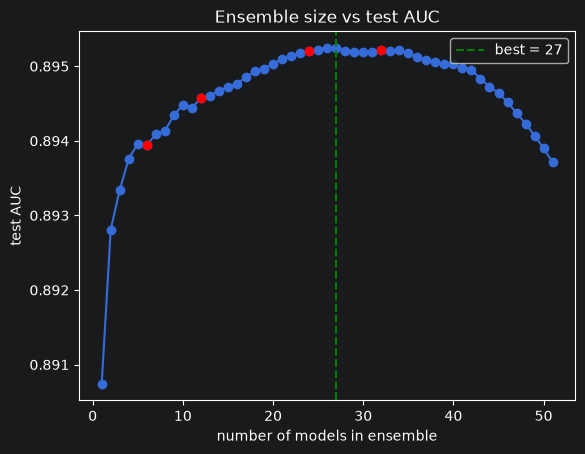

In [18]:
# Ensemble = average of the members' sigmoid probabilities on the test set. Predict
# once per model, then cumulatively average so every ensemble size is cheap to score.
@torch.no_grad()
def predict_probs(info, X_gpu, batch: int = 65536):
    print(f"Running model {info}")
    model = HiggsMLP(
        in_dim=X_gpu.shape[1],
        hidden_layers=info["hidden_layers"],
        last_layer_dropout=info["dropout"],
        all_layer_dropout=info["dropout_all"],
        act_layer=activation_types[info["act"]],
    ).to(DEVICE)
    model.load_state_dict(torch.load(info["pt_path"], map_location=DEVICE))
    model.eval()
    probs = []
    for i in range(0, len(X_gpu), batch):
        probs.append(torch.sigmoid(model(X_gpu[i:i + batch])).float().cpu().numpy())
    return np.concatenate(probs)

ensemble_sizes = [6, 12, 24, 32, 64]
X_test_t = torch.tensor(X_test, device=DEVICE)

n_max = min(max(ensemble_sizes), len(best_models))
member_probs = [predict_probs(r, X_test_t) for r in best_models[:n_max]]

# Cumulative ensemble: aucs[n - 1] = test AUC of averaging the top-n distinct models.
running = np.zeros(len(y_test), dtype=np.float64)
aucs = []
for n, p in enumerate(member_probs, start=1):
    running += p
    aucs.append(roc_auc_score(y_test, running / n))

for n in ensemble_sizes:
    if n <= n_max:
        print(f"Ensemble of {n:2d} models - test AUC {aucs[n - 1]:.5f}")

requested = [n for n in ensemble_sizes if n <= n_max] or [n_max]
best_n = max(range(len(aucs)), key=lambda n: aucs[n - 1])
print(f"\nBest ensemble size: {best_n} models (test AUC {aucs[best_n - 1]:.5f})")

plt.figure()
plt.plot(range(1, n_max + 1), aucs, marker="o")
for n in requested:
    plt.scatter([n], [aucs[n - 1]], color="red", zorder=3)
plt.axvline(best_n, color="green", linestyle="--", label=f"best = {best_n}")
plt.xlabel("number of models in ensemble")
plt.ylabel("test AUC")
plt.title("Ensemble size vs test AUC")
plt.legend()
plt.show()